# 🎬 Análisis Exploratorio de Datos — Recomendador de Películas

Notebook para explorar el dataset del proyecto: cantidad de películas, disponibilidad de posters, distribución por género y análisis temporal.

## 1. Importar Librerías Necesarias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import os
import warnings

warnings.filterwarnings("ignore")

# Estilo visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Cargar y Explorar el Dataset

In [2]:
# Rutas relativas desde la carpeta notebooks/
BASE_DIR = Path("..") 
METADATA_PATH = BASE_DIR / "data" / "processed" / "metadata.csv"
MOVIES_RAW_PATH = BASE_DIR / "data" / "raw" / "movies.csv"
POSTERS_DIR = BASE_DIR / "data" / "posters"

# Cargar datasets
df = pd.read_csv(METADATA_PATH)
df_raw = pd.read_csv(MOVIES_RAW_PATH)

print(f"Filas en metadata.csv : {len(df):,}")
print(f"Filas en movies.csv   : {len(df_raw):,}")
print()
df.head()

Filas en metadata.csv : 86,154
Filas en movies.csv   : 87,585



,movieId,tmdbId,title,genres,overview,poster_path
0,7,11860,Sabrina,"Romance, Drama, Comedy","After her return from school in Paris, a playb...",data\posters\11860.jpg
1,2,8844,Jumanji,"Adventure, Fantasy, Family",When siblings Judy and Peter discover an encha...,data\posters\8844.jpg
2,3,15602,Grumpier Old Men,"Romance, Comedy",A family wedding reignites the ancient feud be...,data\posters\15602.jpg
3,8,45325,Tom and Huck,"Family, Action, Adventure, Drama","A mischievous young boy, Tom Sawyer, witnesses...",data\posters\45325.jpg
4,5,11862,Father of the Bride Part II,"Comedy, Family",Just when George Banks has recovered from his ...,data\posters\11862.jpg


In [3]:
print("=== Tipos de datos y valores nulos ===")
df.info()
print()
print("=== Estadísticas básicas ===")
df.describe(include="all")

=== Tipos de datos y valores nulos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86154 entries, 0 to 86153
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   movieId      86154 non-null  int64 
 1   tmdbId       86154 non-null  int64 
 2   title        86154 non-null  object
 3   genres       85422 non-null  object
 4   overview     85903 non-null  object
 5   poster_path  85082 non-null  object
dtypes: int64(2), object(4)
memory usage: 3.9+ MB

=== Estadísticas básicas ===


,movieId,tmdbId,title,genres,overview,poster_path
count,86154.000000,8.615400e+04,86154,85422,85903,85082
unique,NaN,NaN,78248,6663,85735,85047
top,NaN,NaN,Cinderella,Drama,"In 19th century France, Jean Valjean, a man im...",data\posters\24487.jpg
freq,NaN,NaN,19,9367,7,2
mean,157328.391973,2.395478e+05,NaN,NaN,NaN,NaN
std,79184.381507,2.462797e+05,NaN,NaN,NaN,NaN
min,1.000000,2.000000e+00,NaN,NaN,NaN,NaN
25%,112185.500000,4.638775e+04,NaN,NaN,NaN,NaN
50%,165454.000000,1.367960e+05,NaN,NaN,NaN,NaN
75%,213076.500000,3.789410e+05,NaN,NaN,NaN,NaN


## 3. Análisis de Cantidad de Películas

In [4]:
total_procesadas = len(df)
total_raw = len(df_raw)
total_con_overview = df["overview"].notna().sum()
total_sin_overview = df["overview"].isna().sum()

print("=" * 40)
print("  RESUMEN GENERAL DEL DATASET")
print("=" * 40)
print(f"  Películas en dataset raw     : {total_raw:,}")
print(f"  Películas procesadas (index) : {total_procesadas:,}")
print(f"  Con descripción (overview)   : {total_con_overview:,}")
print(f"  Sin descripción              : {total_sin_overview:,}")
print("=" * 40)

  RESUMEN GENERAL DEL DATASET
  Películas en dataset raw     : 87,585
  Películas procesadas (index) : 86,154
  Con descripción (overview)   : 85,903
  Sin descripción              : 251


## 4. Análisis de Películas con Posters

Películas CON poster en disco : 85,082  (98.8%)
Películas SIN poster en disco : 1,072  (1.2%)


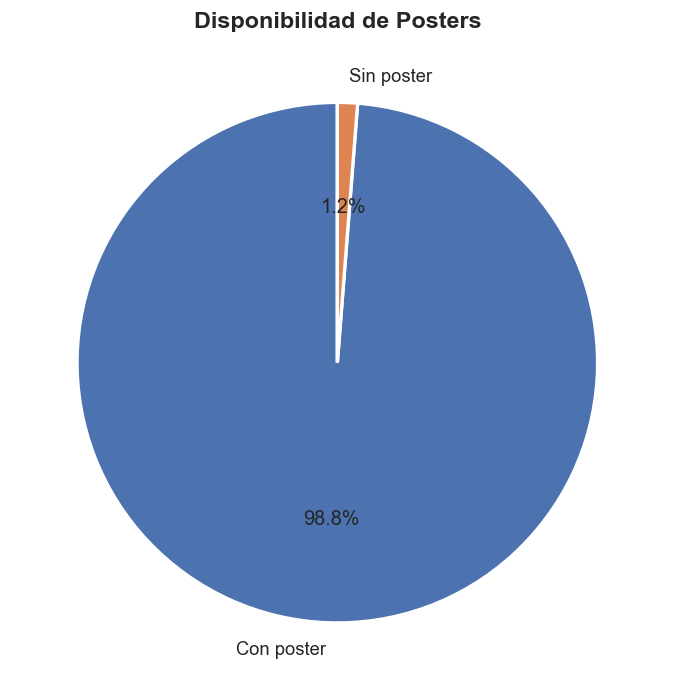

In [5]:
# Verificar existencia real de cada archivo de poster en disco
def poster_exists(path_str):
    if pd.isna(path_str):
        return False
    # La ruta en el CSV es relativa a la raíz del proyecto
    full_path = BASE_DIR / path_str
    return full_path.exists()

df["poster_exists"] = df["poster_path"].apply(poster_exists)

con_poster = df["poster_exists"].sum()
sin_poster = len(df) - con_poster

print(f"Películas CON poster en disco : {con_poster:,}  ({con_poster/len(df)*100:.1f}%)")
print(f"Películas SIN poster en disco : {sin_poster:,}  ({sin_poster/len(df)*100:.1f}%)")

# Gráfico de pastel
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [con_poster, sin_poster],
    labels=["Con poster", "Sin poster"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C72B0", "#DD8452"],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
ax.set_title("Disponibilidad de Posters", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. División por Género

Géneros únicos encontrados: 19

genres
Drama              37474
Comedy             26078
Thriller           13488
Romance            12771
Action             10389
Documentary        10063
Horror              9793
Crime               9044
Adventure           6303
Family              5441
Science Fiction     5388
Mystery             5195
TV Movie            5007
Fantasy             4901
Animation           4893
Music               3748
History             3411
War                 2628
Western             1940


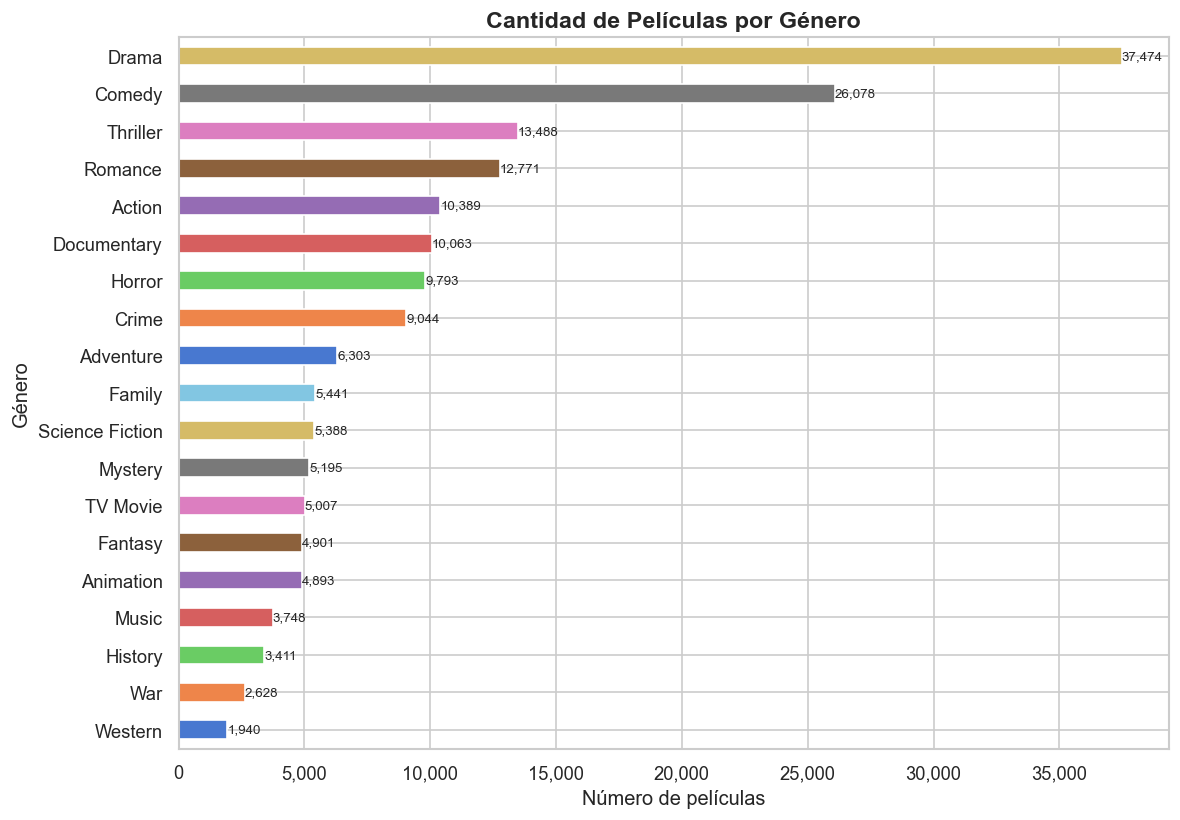

In [6]:
# Los géneros en metadata.csv están separados por ", "
genre_series = (
    df["genres"]
    .dropna()
    .str.split(", ")
    .explode()
    .str.strip()
)

genre_counts = genre_series.value_counts()

print(f"Géneros únicos encontrados: {genre_counts.shape[0]}")
print()
print(genre_counts.to_string())

# Gráfico de barras horizontales
fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("muted", len(genre_counts))
genre_counts.sort_values().plot(kind="barh", ax=ax, color=colors)

ax.set_title("Cantidad de Películas por Género", fontsize=14, fontweight="bold")
ax.set_xlabel("Número de películas")
ax.set_ylabel("Género")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar in ax.patches:
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}",
        va="center", fontsize=8,
    )

plt.tight_layout()
plt.show()

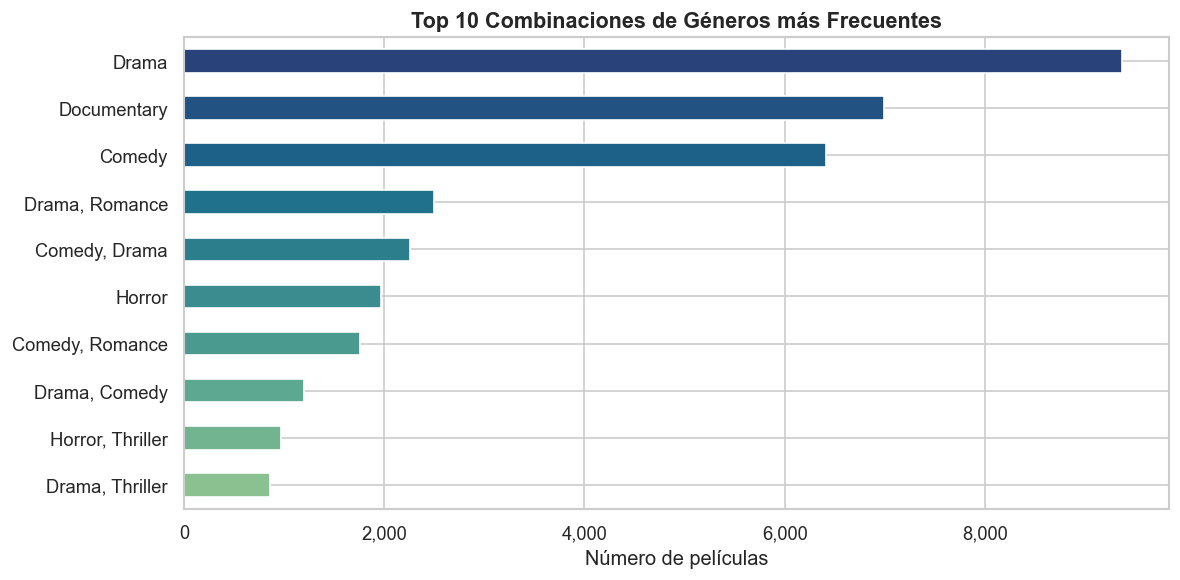

In [7]:
# Top 10 combinaciones de géneros más frecuentes
combo_counts = df["genres"].dropna().value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
combo_counts.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("crest", 10))
ax.set_title("Top 10 Combinaciones de Géneros más Frecuentes", fontsize=13, fontweight="bold")
ax.set_xlabel("Número de películas")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 6. Análisis de Distribución Temporal

El año de lanzamiento se extrae del título en el dataset raw (formato `Título (YYYY)`).

Rango de años: 1900 – 2023
Películas con año identificado: 86,753 / 87,585


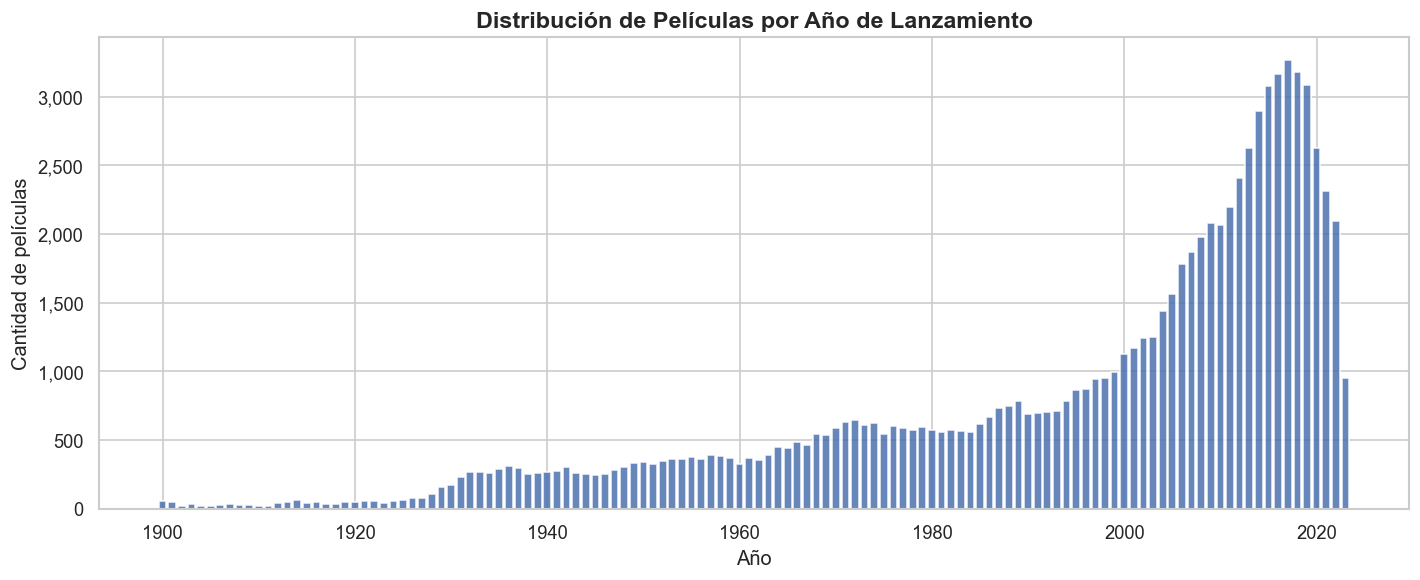

In [8]:
# Extraer año del título (ej: "Toy Story (1995)" -> 1995)
df_raw["year"] = df_raw["title"].str.extract(r"\((\d{4})\)").astype("Int64")

# Filtrar años válidos (1900 - 2030)
df_years = df_raw.dropna(subset=["year"])
df_years = df_years[(df_years["year"] >= 1900) & (df_years["year"] <= 2030)]

year_counts = df_years["year"].value_counts().sort_index()

print(f"Rango de años: {year_counts.index.min()} – {year_counts.index.max()}")
print(f"Películas con año identificado: {len(df_years):,} / {len(df_raw):,}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(year_counts.index, year_counts.values, color="#4C72B0", width=0.8, alpha=0.85)
ax.set_title("Distribución de Películas por Año de Lanzamiento", fontsize=14, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de películas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

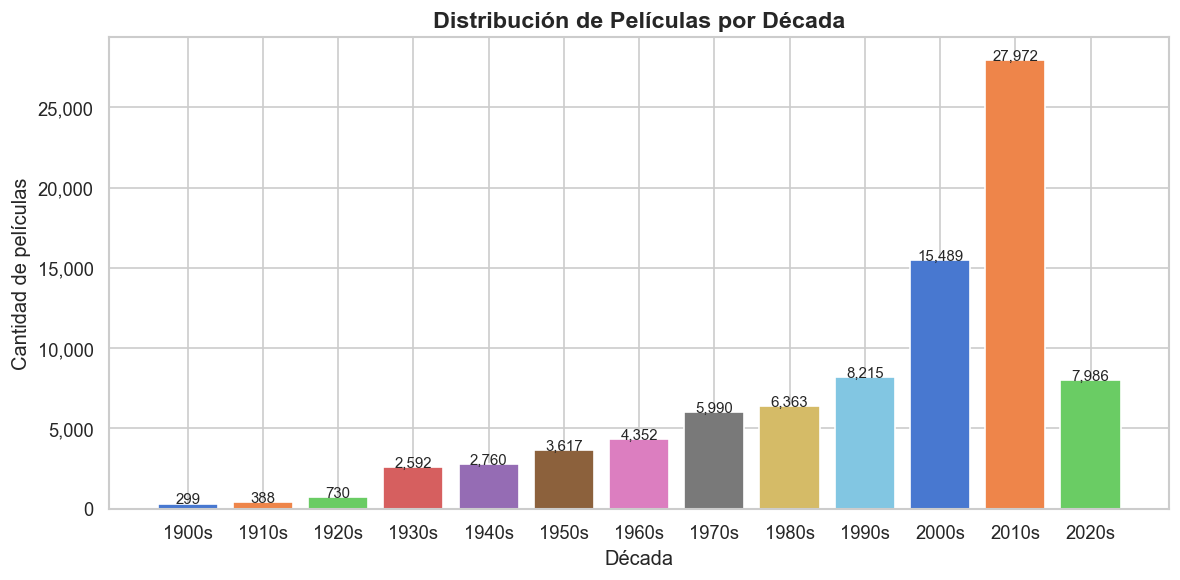

In [9]:
# Distribución por década
df_years = df_years.copy()
df_years["decade"] = (df_years["year"] // 10 * 10).astype(int)
decade_counts = df_years["decade"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    decade_counts.index.astype(str) + "s",
    decade_counts.values,
    color=sns.color_palette("muted", len(decade_counts)),
)
ax.set_title("Distribución de Películas por Década", fontsize=14, fontweight="bold")
ax.set_xlabel("Década")
ax.set_ylabel("Cantidad de películas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=9,
    )

plt.tight_layout()
plt.show()

## 7. Dashboard — Estadísticas Generales

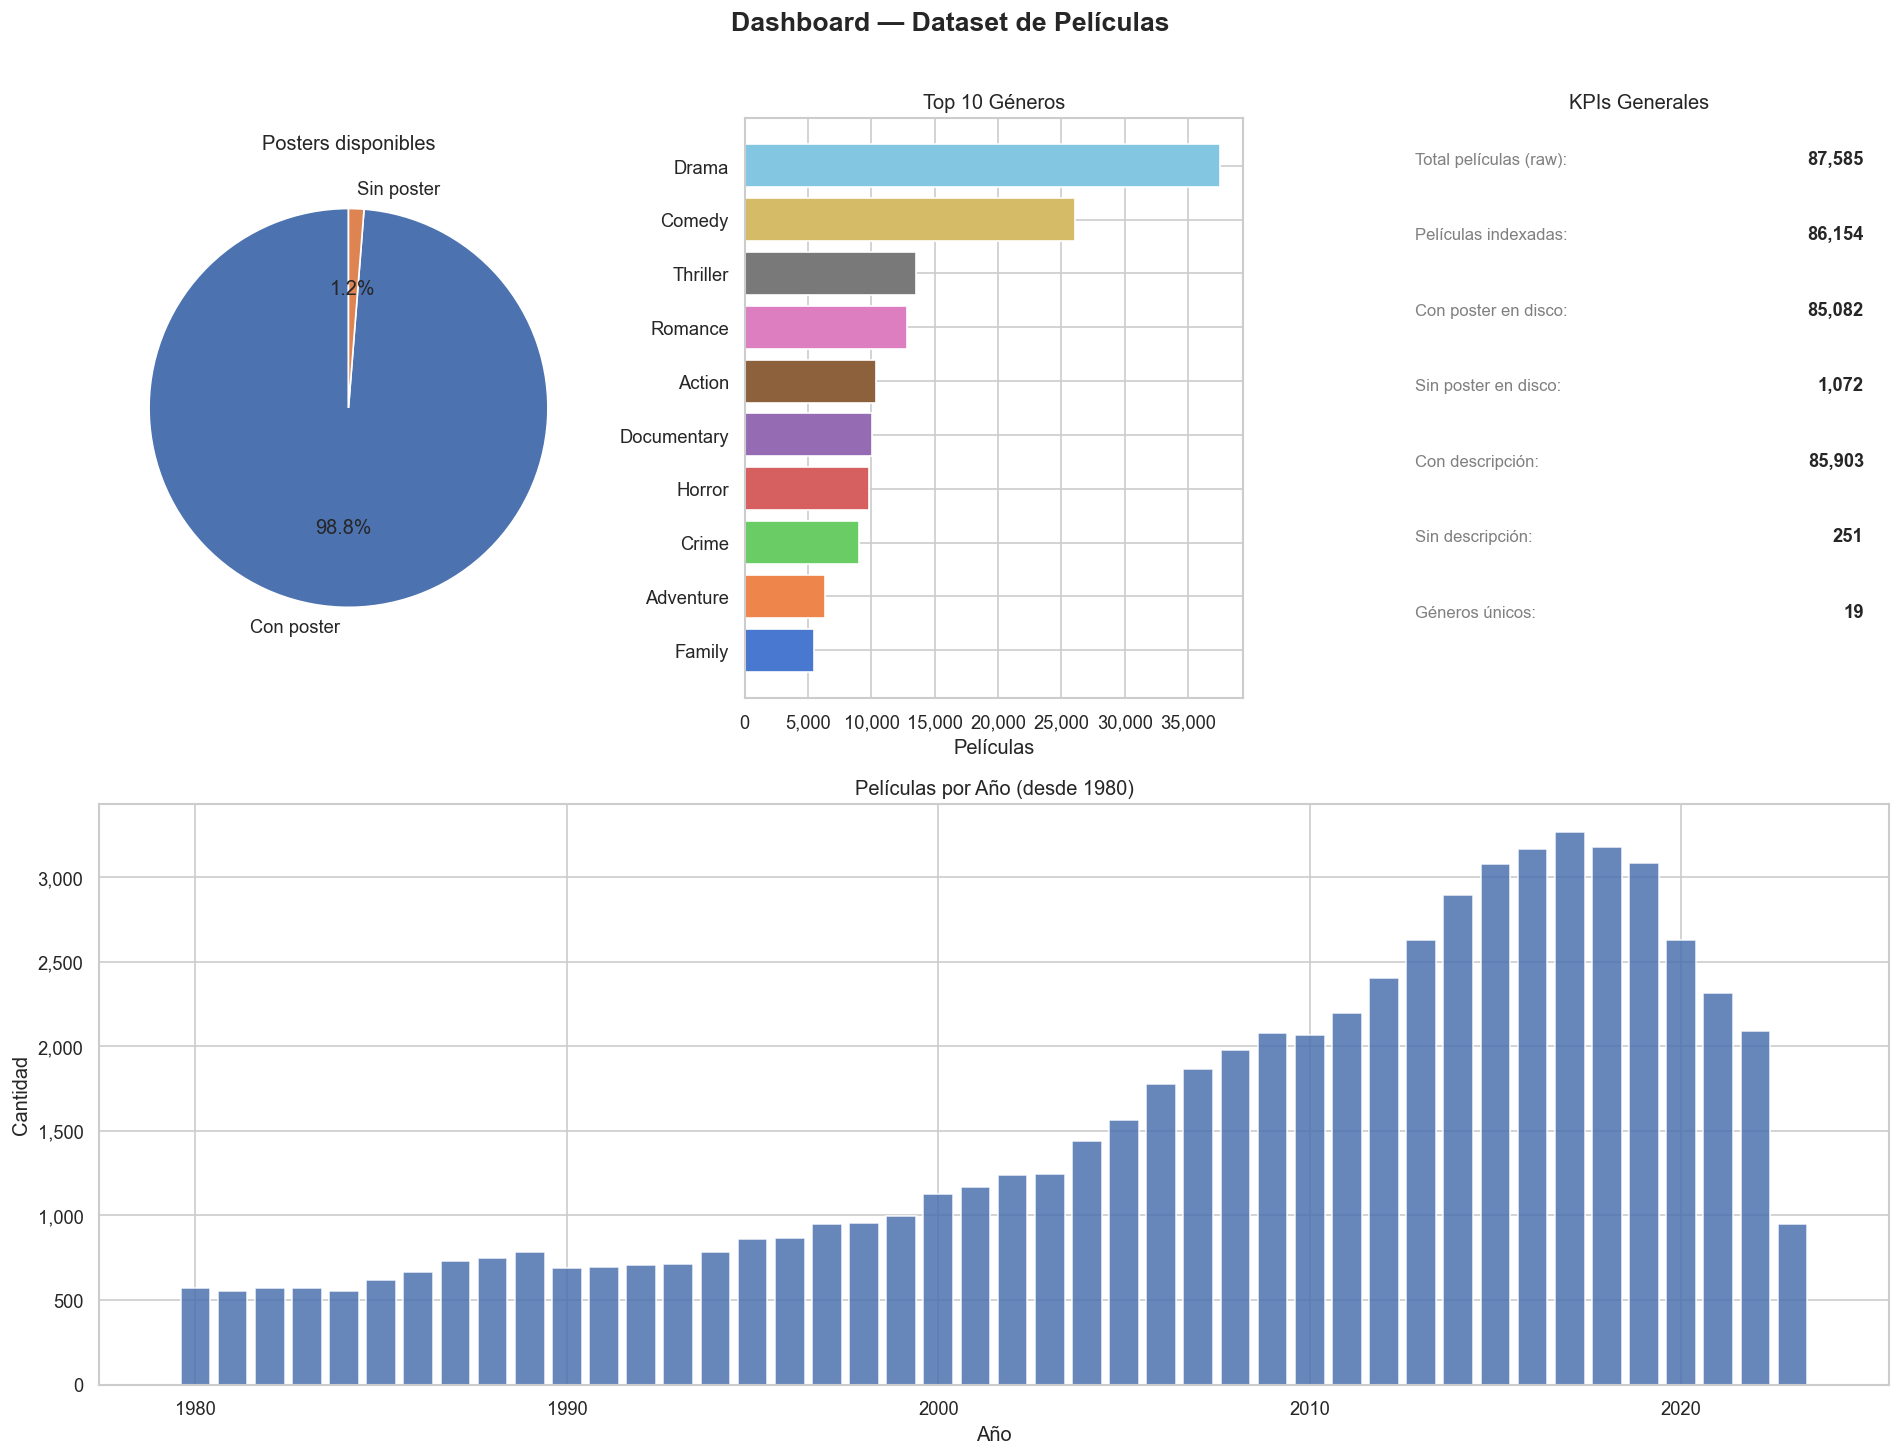

In [10]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Dashboard — Dataset de Películas", fontsize=16, fontweight="bold", y=1.01)

# ── Subplot 1: Pie de posters ──────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
ax1.pie(
    [con_poster, sin_poster],
    labels=["Con poster", "Sin poster"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C72B0", "#DD8452"],
    wedgeprops={"edgecolor": "white"},
)
ax1.set_title("Posters disponibles")

# ── Subplot 2: Top 10 géneros ──────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
top10 = genre_counts.head(10).sort_values()
ax2.barh(top10.index, top10.values, color=sns.color_palette("muted", 10))
ax2.set_title("Top 10 Géneros")
ax2.set_xlabel("Películas")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Subplot 3: KPIs de texto ───────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
ax3.axis("off")
kpis = [
    ("Total películas (raw)", f"{total_raw:,}"),
    ("Películas indexadas", f"{total_procesadas:,}"),
    ("Con poster en disco", f"{con_poster:,}"),
    ("Sin poster en disco", f"{sin_poster:,}"),
    ("Con descripción", f"{total_con_overview:,}"),
    ("Sin descripción", f"{total_sin_overview:,}"),
    ("Géneros únicos", f"{genre_counts.shape[0]}"),
]
for i, (label, val) in enumerate(kpis):
    ax3.text(0.05, 0.92 - i * 0.13, f"{label}:", fontsize=10, color="gray", transform=ax3.transAxes)
    ax3.text(0.95, 0.92 - i * 0.13, val, fontsize=11, fontweight="bold", ha="right", transform=ax3.transAxes)
ax3.set_title("KPIs Generales")

# ── Subplot 4: Películas por año (solo desde 1980) ─────────────────────────
ax4 = fig.add_subplot(2, 1, 2)
recent = year_counts[year_counts.index >= 1980]
ax4.bar(recent.index, recent.values, color="#4C72B0", width=0.8, alpha=0.85)
ax4.set_title("Películas por Año (desde 1980)")
ax4.set_xlabel("Año")
ax4.set_ylabel("Cantidad")
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()